In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/processed/cleaned_telco.csv")

In [5]:
df.head(10)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
5,4412-YLTKF,Female,72,No,Yes,No,Yes,1,United States,California,...,10,89.91,2235.41,1,Churned,Yes,95,4638,Competitor,Competitor had better devices
6,0390-DCFDQ,Female,76,No,Yes,Yes,Yes,2,United States,California,...,0,15.28,85.73,2,Churned,Yes,76,3964,Other,Don't know
7,3445-HXXGF,Male,66,No,Yes,Yes,No,0,United States,California,...,0,0.00,2610.25,1,Churned,Yes,91,5444,Dissatisfaction,Service dissatisfaction
8,2656-FMOKZ,Female,70,No,Yes,No,Yes,2,United States,California,...,0,661.05,1806.75,2,Churned,Yes,91,5717,Dissatisfaction,Limited range of services
9,2070-FNEXE,Female,77,No,Yes,No,Yes,2,United States,California,...,0,188.65,681.20,2,Churned,Yes,81,4419,Price,Lack of affordable download/upload speed


In [7]:
df.shape

(7043, 50)

# Exploratory Data Analysis

## Business Objective

The purpose of this analysis is to identify factors associated with customer churn and generate actionable business insights that can support customer retention strategies.

Key Questions:

1. What is the overall churn rate?
2. Which customer segments churn the most?
3. Does customer satisfaction influence churn?
4. Which services are associated with churn?
5. What revenue is at risk due to churn?
6. What are the primary reasons customers leave?

What is the overall churn rate? 

In [8]:
df["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [10]:
df["Customer Status"].value_counts(normalize=True)*100 

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64

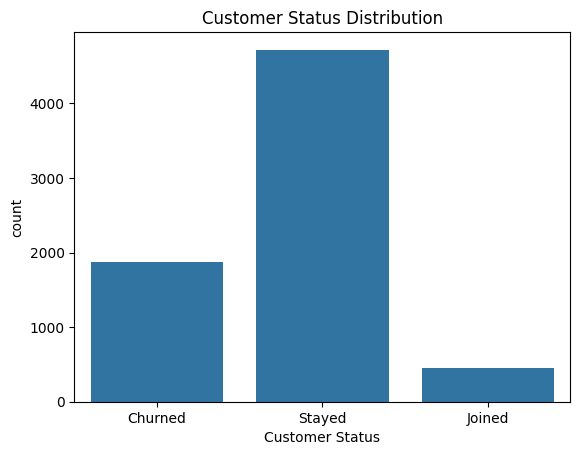

In [11]:
plt.figure()
sns.countplot(
    data=df,
    x="Customer Status")
plt.title("Customer Status Distribution")
plt.show()

We could see majority of customer stayed in the company, while the smaller percentage churned. Understanding the characteristics of churned customers will help identify ooportunities for retention initiatives.

In [12]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [27]:
churn_rate = ( df["Churn Label"].value_counts(normalize=True)["Yes"]*100)

In [29]:
print(round(churn_rate,2))

26.54


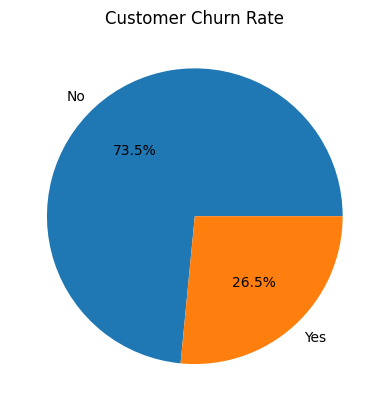

In [21]:
plt.figure()
df["Churn Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%")
plt.title("Customer Churn Rate")
plt.ylabel("")
plt.show()

2. Which customer segments churn the most?

In [24]:
#contract type
contract_churn = pd.crosstab(df["Contract"],
                             df["Churn Label"],
                             normalize="index")["Yes"] * 100
print(round(contract_churn, 2))


Contract
Month-to-Month    45.84
One Year          10.71
Two Year           2.55
Name: Yes, dtype: float64


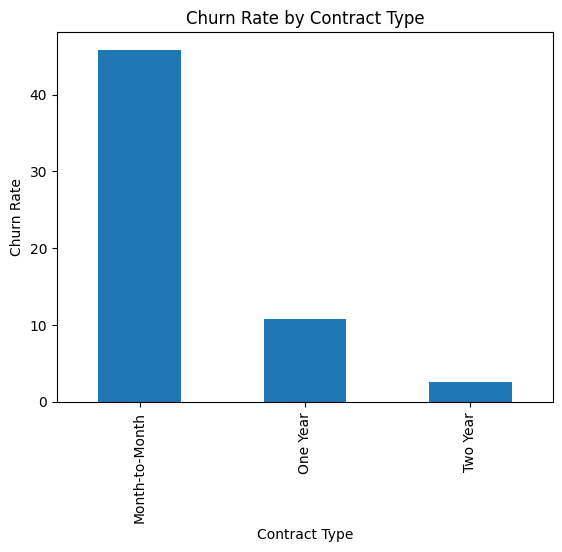

In [55]:
plt.figure()
contract_churn.sort_values(ascending= False).plot(
    kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()

Month-to-Month customers are the highest-risk segment

In [43]:
#age group
df["Age Segment"] = np.select([ 
    df["Under 30"] == "Yes",
    df["Senior Citizen"] == "Yes"],
                              ["Under 30", "Senior"],
                              default ="30-64"
                             )


In [57]:
age_segment = pd.crosstab(df["Age Segment"], df["Churn Label"], normalize="index")["Yes"]*100
print(age_segment)

Age Segment
30-64       24.200000
Senior      41.681261
Under 30    21.698787
Name: Yes, dtype: float64


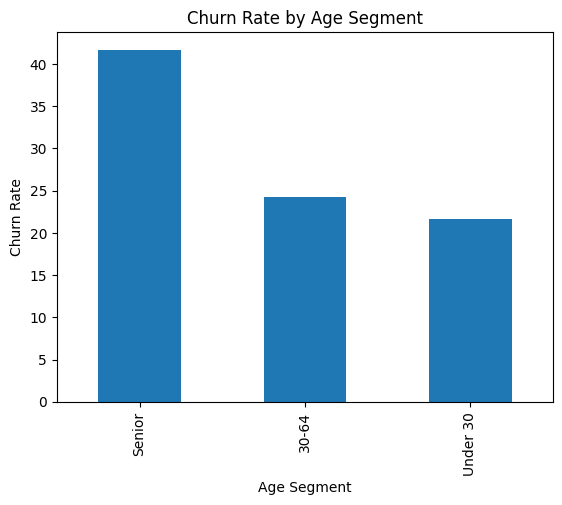

In [61]:
plt.figure()
age_segment.sort_values(ascending= False).plot(
    kind="bar")
plt.title("Churn Rate by Age Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Age Segment")
plt.show()

Senior citizen churned at higher percentage with 41.68%

In [72]:
#satisfaction score
satisfaction= pd.crosstab(df["Satisfaction Score"], df["Churn Label"], normalize="index")*100
print(satisfaction)

Churn Label                 No         Yes
Satisfaction Score                        
1                     0.000000  100.000000
2                     0.000000  100.000000
3                    83.902439   16.097561
4                   100.000000    0.000000
5                   100.000000    0.000000


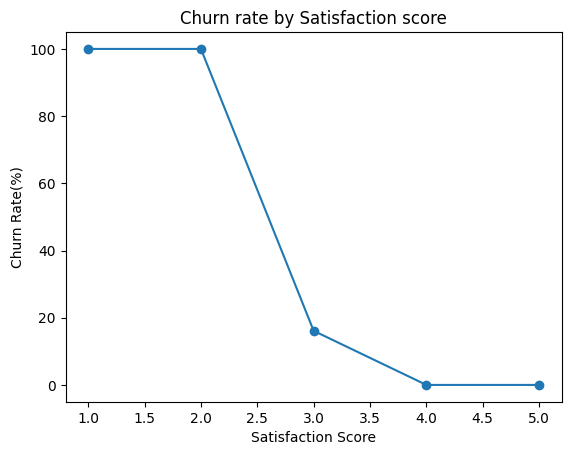

In [75]:
plt.figure()
satisfaction["Yes"].plot(
    marker="o")
plt.title("Churn rate by Satisfaction score")
plt.ylabel("Churn Rate(%)")
plt.show()

Dissatified customer churned more often.

In [62]:
#internet type
internet_type = pd.crosstab(df["Internet Type"], df["Churn Label"], normalize="index")["Yes"]*100
print(internet_type)

Internet Type
Cable          25.662651
DSL            18.583535
Fiber Optic    40.724876
No Internet     7.404980
Name: Yes, dtype: float64


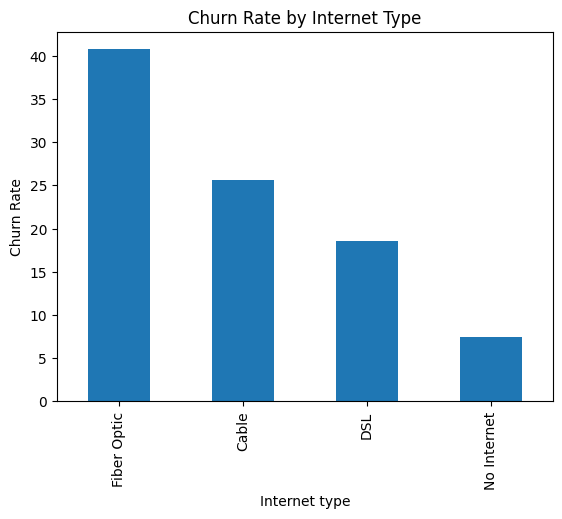

In [64]:
plt.figure()
internet_type.sort_values(ascending = False).plot(
    kind="bar")
plt.title("Churn Rate by Internet Type")
plt.xlabel("Internet type")
plt.ylabel("Churn Rate")
plt.show()


Customers with Fiber Optic churned more at 40.72%.
Fiber Optic customers represent the highest-risk segment and should be the focus of retention initiatives.
Additional investigation should be conducted to determine the root causes of Fiber Optic customer attrition.

In [48]:
#offer 
pd.crosstab(df["Offer"], df["Churn Label"], normalize="index")["Yes"]*100

Offer
No Offer    27.108589
Offer A      6.730769
Offer B     12.257282
Offer C     22.891566
Offer D     26.744186
Offer E     52.919255
Name: Yes, dtype: float64

Customer with Offer E churned represent the highest-risk segment with 52.91% churn rate.

In [49]:
#Premium Tech Support
pd.crosstab(df["Premium Tech Support"], df["Churn Label"], normalize="index")*100

Churn Label,No,Yes
Premium Tech Support,,
No,68.813763,31.186237
Yes,84.833659,15.166341


Customers with no premium tech support has higher churn rate with 31.18%

In [82]:
df.groupby("Churn Label")["Total Revenue"].sum()

Churn Label
No     17686671.87
Yes     3684459.82
Name: Total Revenue, dtype: float64

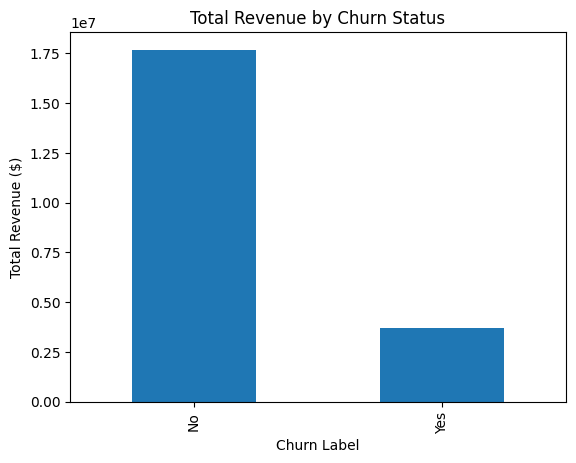

In [85]:
plt.figure()
df.groupby("Churn Label")["Total Revenue"].sum().plot(
    kind="bar")

plt.title("Total Revenue by Churn Status")
plt.ylabel("Total Revenue ($)")
plt.show()

In [83]:
df.groupby("Churn Label")["Monthly Charge"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charge, dtype: float64

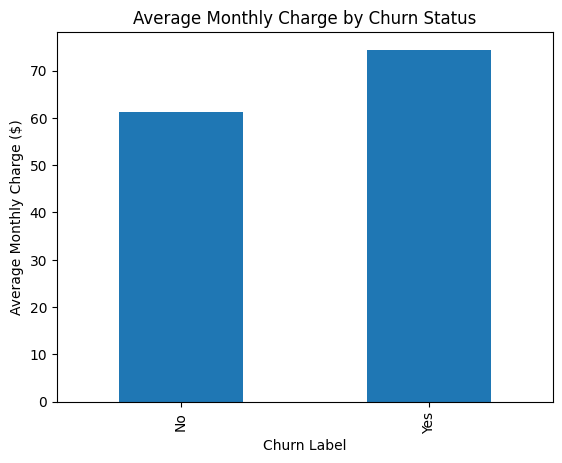

In [84]:
plt.figure()
df.groupby("Churn Label")["Monthly Charge"].mean().plot(
    kind="bar")

plt.title("Average Monthly Charge by Churn Status")
plt.ylabel("Average Monthly Charge ($)")
plt.show()

In [80]:
#Churn Reason 
df["Churn Reason"].value_counts()

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Long distance charges                         64
Service dissatisfaction                       63
Moved                                         46
Extra data charges                            39
Limited range of services                     37
Poor expertise of online support              31
Lack of affordable download/upload speed      30
Lack of self-service on Website               29
Poor expertise of phone support               12
Deceased                                       6
Name: c

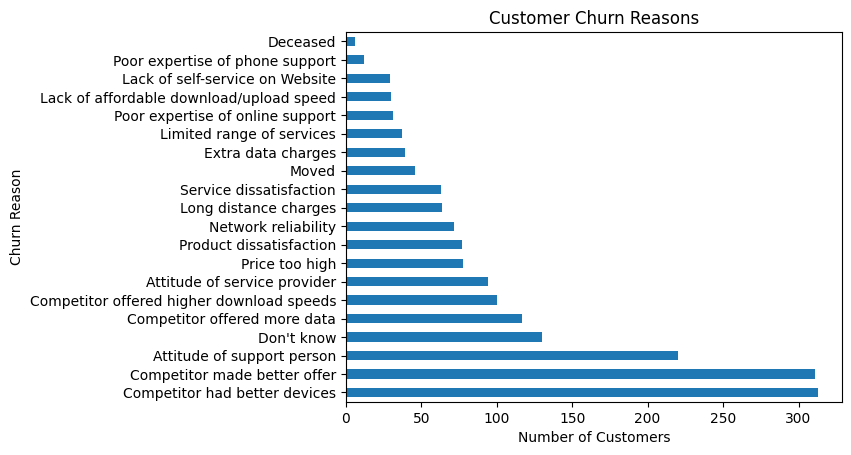

In [81]:
plt.figure()
df["Churn Reason"].value_counts().plot(
    kind="barh")
plt.title("Customer Churn Reasons")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.show()